In [193]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('~/styles/clarke-default.mplstyle')
from nestpy import nestpy
import trimesh

### Function to get S2 photons from energy using NEST

In [194]:
nc = nestpy.NESTcalc(nestpy.VDetector())

energy = 100.
A = 131.293
Z = 54.
density = 2.9 # g/cm^3
drift_field = 200. # V/cm
ph_per_elec = 50
ph_smearing = 0.25

def get_S2_photons(energy):
    NR_yields = nc.GetYields(nestpy.INTERACTION_TYPE(0), energy, density, drift_field)
    NR_quanta = nc.GetQuanta(NR_yields, density)
    n_elec = NR_quanta.electrons
    return int(np.random.normal(ph_per_elec*n_elec, ph_per_elec*ph_smearing))

### Load simulated data from Jingke

Text(0.5, 1.0, 'Spatial separation for DD neutrons')

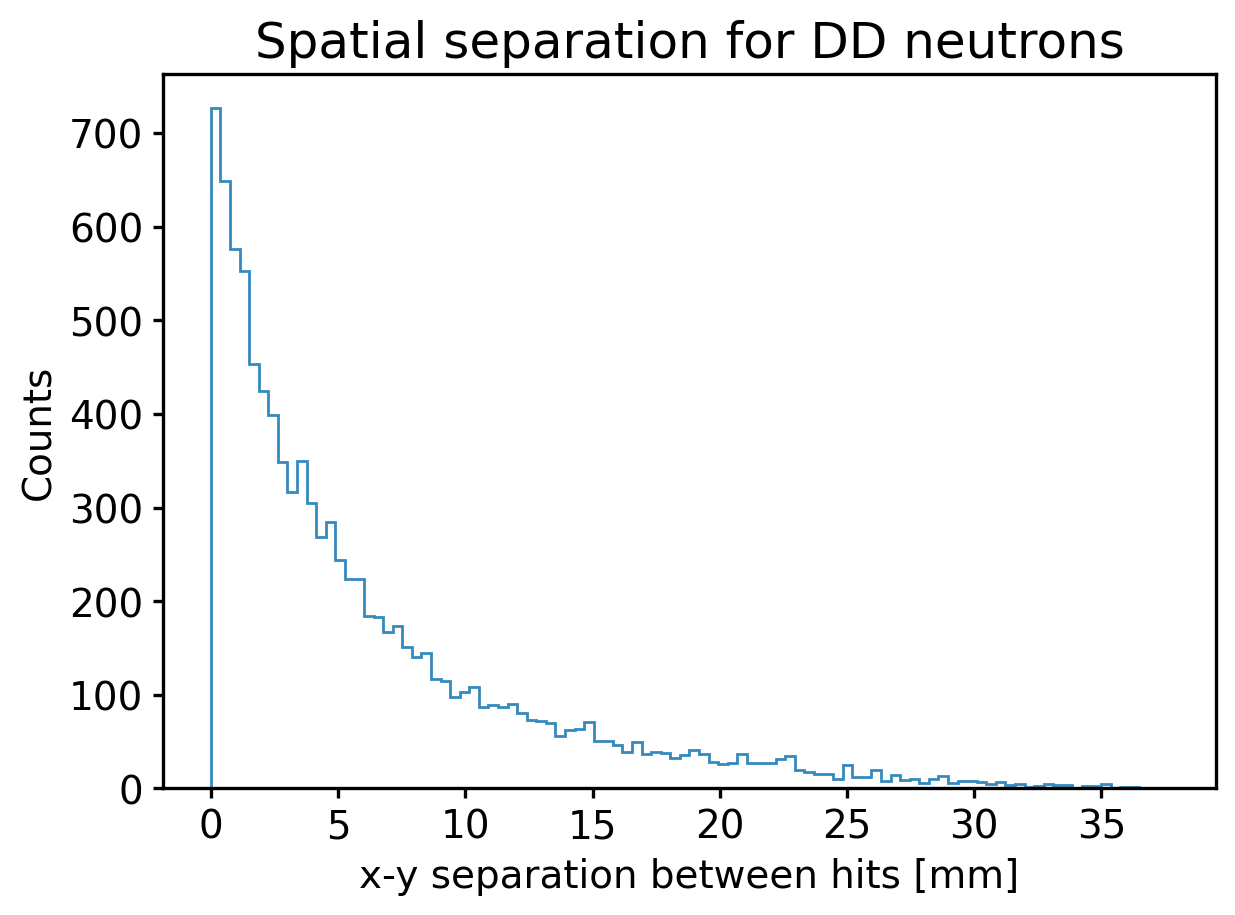

In [195]:
sim_data = np.genfromtxt('data/MS2TPC4keVDD.txt', skip_header=1)
sim_data.shape

def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

pos1 = sim_data[:, 2:4]
pos2 = sim_data[:, 6:8]

seps = spatial_sep(pos1, pos2)

fig, ax = plt.subplots()
ax.hist(seps, histtype='step', bins=100)
ax.set_xlabel('x-y separation between hits [mm]')
ax.set_ylabel('Counts')
ax.set_title('Spatial separation for DD neutrons')
#fig.savefig('/home/clarke/figures/sim_data_seps.png')

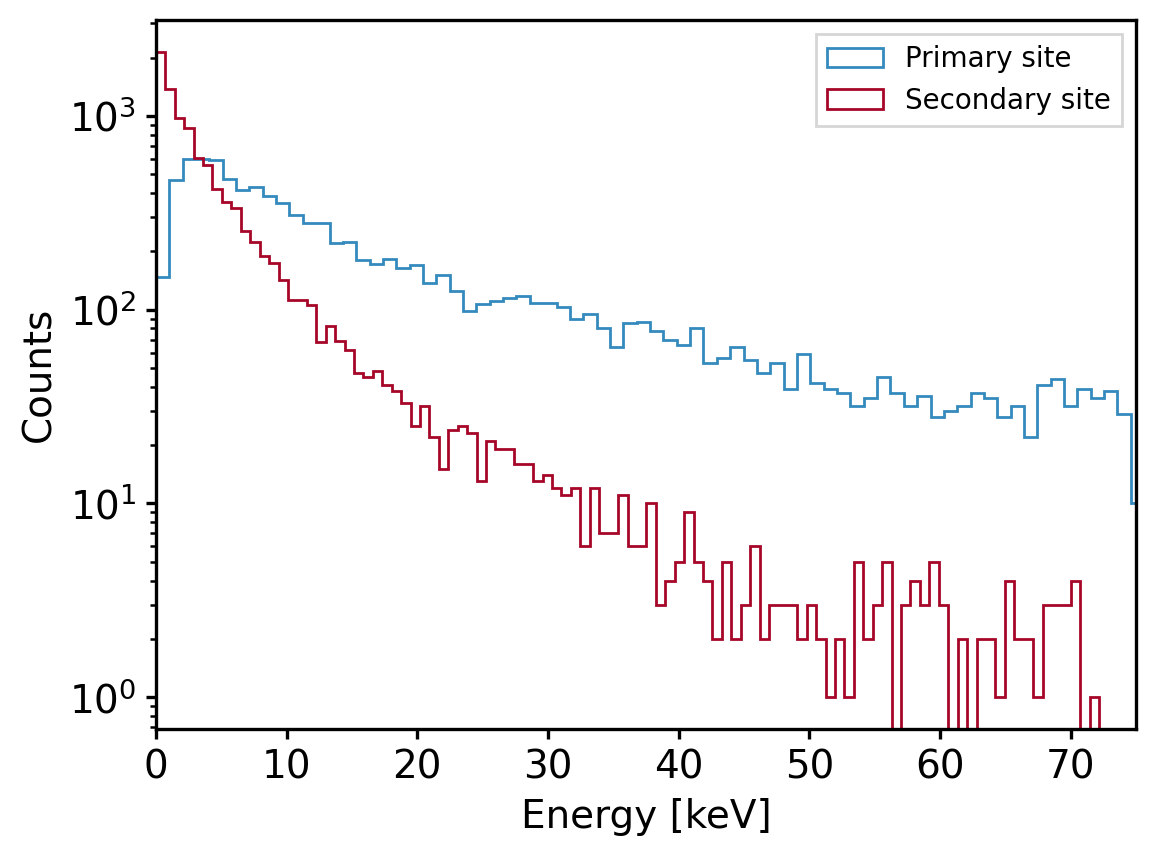

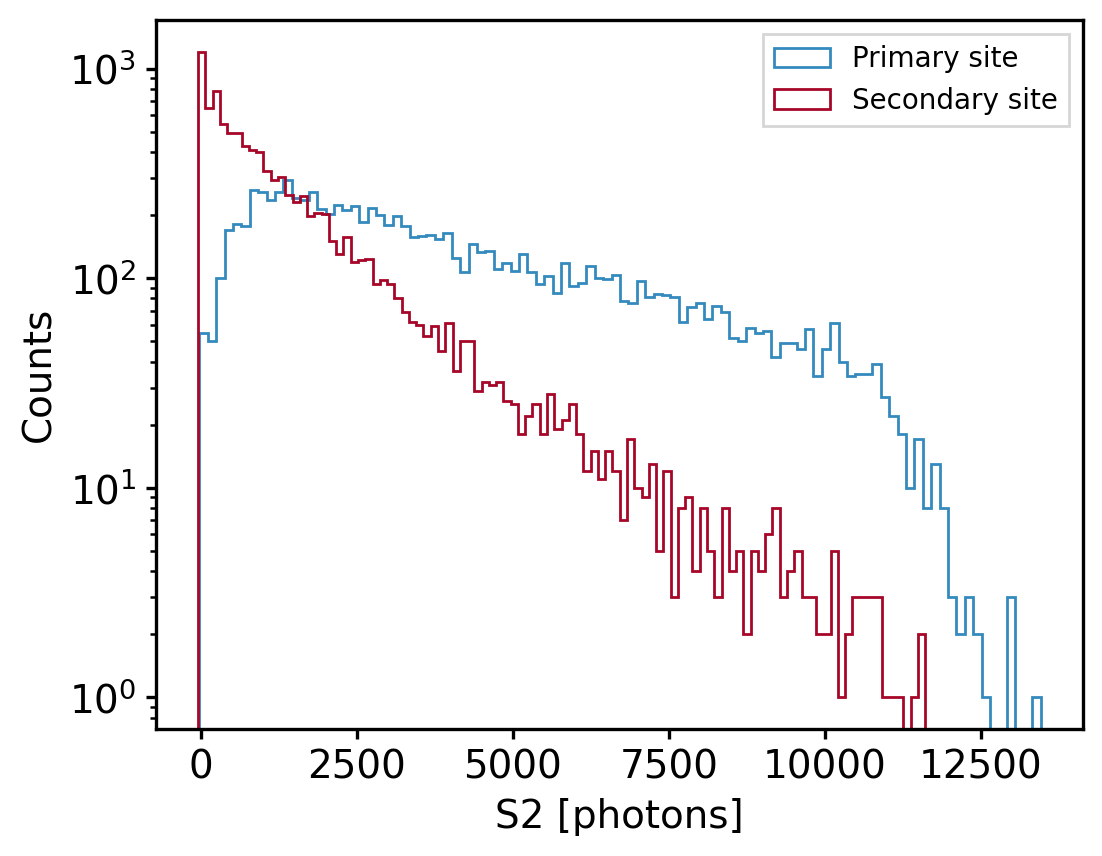

In [249]:
energy_1 = sim_data[:,1]
energy_2 = sim_data[:,5]

energy_l = np.amax(np.vstack((energy_1, energy_2)), axis=0)
energy_s = np.amin(np.vstack((energy_1, energy_2)), axis=0)

fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist(energy_l, histtype='step', bins=100, label='Primary site')
ax.hist(energy_s, histtype='step', bins=100, label='Secondary site')
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')
ax.legend()
ax.set_yscale('log')
ax.set_xlim([0, 75])

fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist([get_S2_photons(i) for i in energy_l], histtype='step', bins=100, label='Primary site')
ax.hist([get_S2_photons(i) for i in energy_s], histtype='step', bins=100, label='Secondary site')
ax.set_xlabel('S2 [photons]')
ax.set_ylabel('Counts')
ax.legend()
ax.set_yscale('log')
#ax.set_xlim([0, 75])

### Check that the x-y positions look correct

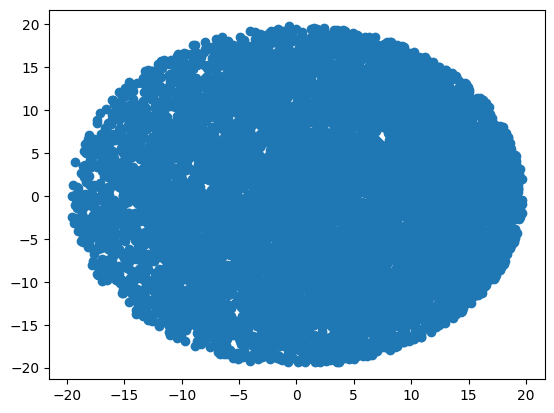

In [29]:
plt.scatter(sim_data[:, 2], sim_data[:, 3])

### Find the z position to attach to the events at the liquid surface

In [49]:
# load the stl file defining the extraction region
# mesh = trimesh.load_mesh('/home/clarke/stl/ExtractionRegion.stl')
mesh = trimesh.load_mesh('/home/clarke/stl/LXe.stl')
vertices = mesh.vertices

# offset to bring extraction region to its actual size
z_offset = 6.493

# find the coordinates and radius
min_z = np.min(vertices[:, 2])
max_z = np.max(vertices[:, 2])

z_pos = max_z + z_offset
print(z_pos)

# find the coordinates and radius
min_z = np.min(vertices[:, 2])
max_z = np.max(vertices[:, 2])
bottom_points = vertices[np.isclose(vertices[:, 2], min_z)]
top_points = vertices[np.isclose(vertices[:, 2], max_z)]
bottom_center = np.mean(bottom_points, axis=0)
top_center = np.mean(top_points, axis=0)
radius = np.mean(np.linalg.norm(bottom_points[:,:2] - bottom_center[:2], axis=1))
height = max_z - min_z

def create_points(n_points=10_000):
    points_rt = np.random.uniform([0., 0.], [radius**2, 2.*np.pi], size=(n_points, 2))
    points_rt[:, 0] = np.sqrt(points_rt[:, 0])
    points_rtz = np.hstack([points_rt, (max_z + z_offset)*np.ones(n_points)[:, np.newaxis]])

    points_xyz = np.zeros_like(points_rtz)
    points_xyz[:, 0] = points_rtz[:, 0] * np.cos(points_rtz[:, 1])
    points_xyz[:, 1] = points_rtz[:, 0] * np.sin(points_rtz[:, 1])
    points_xyz[:, 2] = points_rtz[:, 2]
    return points_xyz

-379.2625847167969


### Save the positions and associated S2s

In [85]:
def create_ms_events(sim_data, prefix, s2_cut=1):
    s2_photons_site1 = np.zeros(sim_data.shape[0])
    s2_photons_site2 = np.zeros(sim_data.shape[0])
    for i, line in enumerate(sim_data):
        s2_photons_site1[i] = get_S2_photons(line[1])
        s2_photons_site2[i] = get_S2_photons(line[5])
    mask = (s2_photons_site1 > s2_cut) & (s2_photons_site2 > s2_cut)
    points1 = np.hstack((sim_data[:, 2:4][mask], \
                         np.ones((len(sim_data), 1))[mask]*z_pos, \
                         s2_photons_site1[:, None][mask]))
    points2 = np.hstack((sim_data[:, 6:8][mask], \
                         np.ones((len(sim_data), 1))[mask]*z_pos, \
                         s2_photons_site2[:, None][mask]))
    np.save(prefix + '_site1.npy', points1, allow_pickle=False)
    np.save(prefix + '_site2.npy', points2, allow_pickle=False)

def create_ss_events(sim_data, prefix, s2_cut=1):
    s2_photons = np.zeros(sim_data.shape[0])
    for i, line in enumerate(sim_data):
        s2_photons[i] = get_S2_photons(line[1] + line[5])
    mask = (s2_photons > s2_cut)
    points = np.hstack((create_points(len(sim_data))[mask], \
                        s2_photons[:, None][mask]))
    np.save(prefix + '_site0.npy', points, allow_pickle=False)

save_prefix = 'chroma-lxe/data/XeNu_LXe_surface_points_JingkeSim'

create_ms_events(sim_data, save_prefix)
create_ss_events(sim_data, save_prefix)

(array([ 32.,  43.,  63., 157., 222., 243., 267., 267., 288., 298., 254.,
        265., 236., 226., 225., 210., 237., 242., 247., 217., 205., 205.,
        219., 195., 186., 165., 182., 159., 170., 175., 156., 146., 174.,
        151., 166., 146., 139., 133., 113., 116., 122., 112., 114., 100.,
         94., 106., 105., 116., 107.,  90.,  98.,  70.,  84.,  70.,  80.,
         87.,  73.,  67.,  53.,  53.,  65.,  50.,  43.,  37.,  43.,  40.,
         26.,  36.,  24.,  32.,  20.,  27.,  16.,  23.,  16.,  20.,   7.,
         10.,   9.,   9.,   9.,   8.,   9.,   8.,   9.,   9.,   4.,   2.,
          4.,   6.,   3.,   2.,   2.,   6.,   1.,   3.,   0.,   1.,   0.,
          1.]),
 array([2.000000e+00, 1.764700e+02, 3.509400e+02, 5.254100e+02,
        6.998800e+02, 8.743500e+02, 1.048820e+03, 1.223290e+03,
        1.397760e+03, 1.572230e+03, 1.746700e+03, 1.921170e+03,
        2.095640e+03, 2.270110e+03, 2.444580e+03, 2.619050e+03,
        2.793520e+03, 2.967990e+03, 3.142460e+03, 3.316930e+03

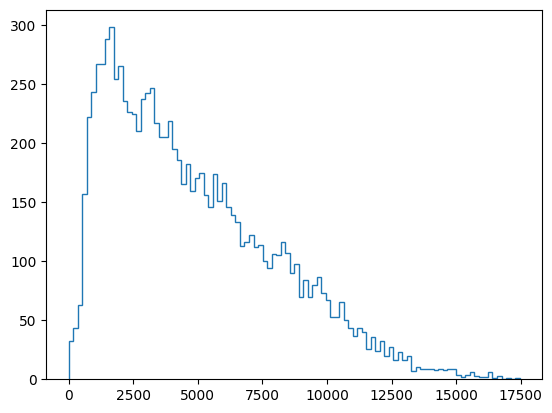

In [86]:
d = np.load('chroma-lxe/data/XeNu_LXe_surface_points_JingkeSim_site0.npy')
plt.hist(d[:, 3], histtype='step', bins=100)

In [81]:
len(d[:, 3][d[:, 3]<0])

0

In [87]:
d[:, -1]

array([5902., 1308., 9520., ..., 3291., 3276., 6390.])

Text(0.5, 1.0, 'x-y separation between hits')

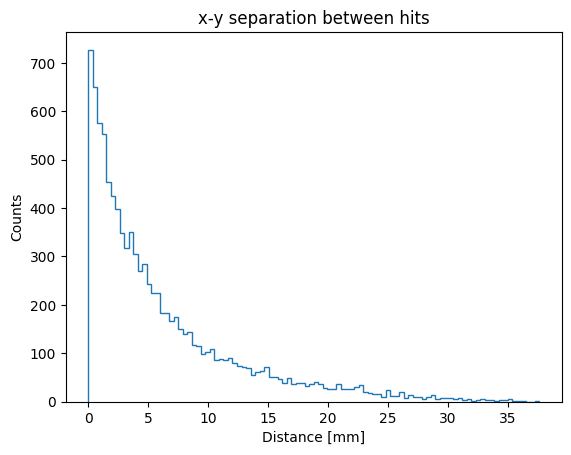

In [90]:
def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

pos1 = sim_data[:, 2:4]
pos2 = sim_data[:, 6:8]

seps = spatial_sep(pos1, pos2)

fig, ax = plt.subplots()
ax.hist(seps, histtype='step', bins=100)
ax.set_xlabel('Distance [mm]')
ax.set_ylabel('Counts')
ax.set_title('x-y separation between hits')

(0.0, 20.0)

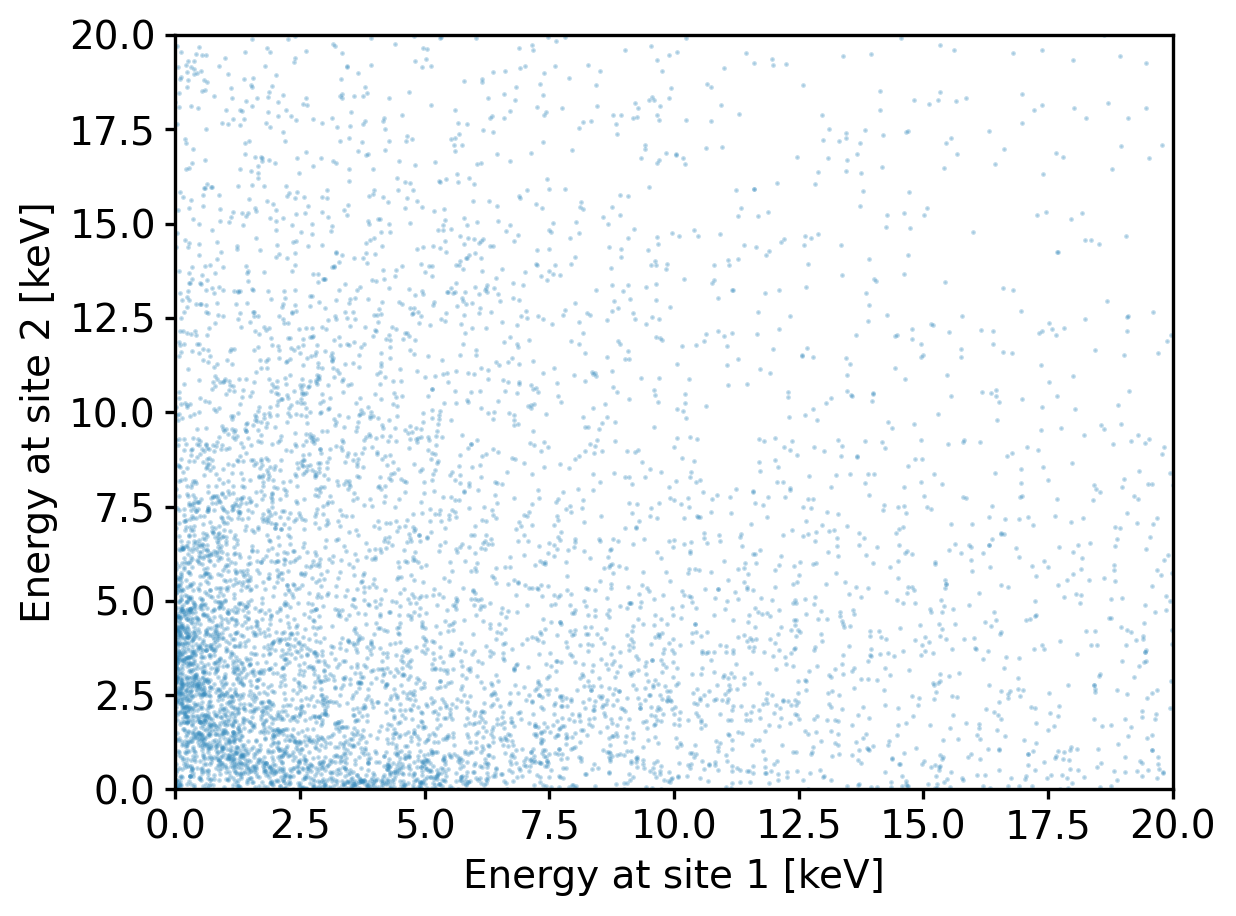

In [105]:
fig, ax = plt.subplots()
ax.scatter(sim_data[:,1], sim_data[:,5], marker='.', s=2, alpha=0.3)
ax.set_xlabel('Energy at site 1 [keV]')
ax.set_ylabel('Energy at site 2 [keV]')
ax.set_xlim([0, 20])
ax.set_ylim([0, 20])

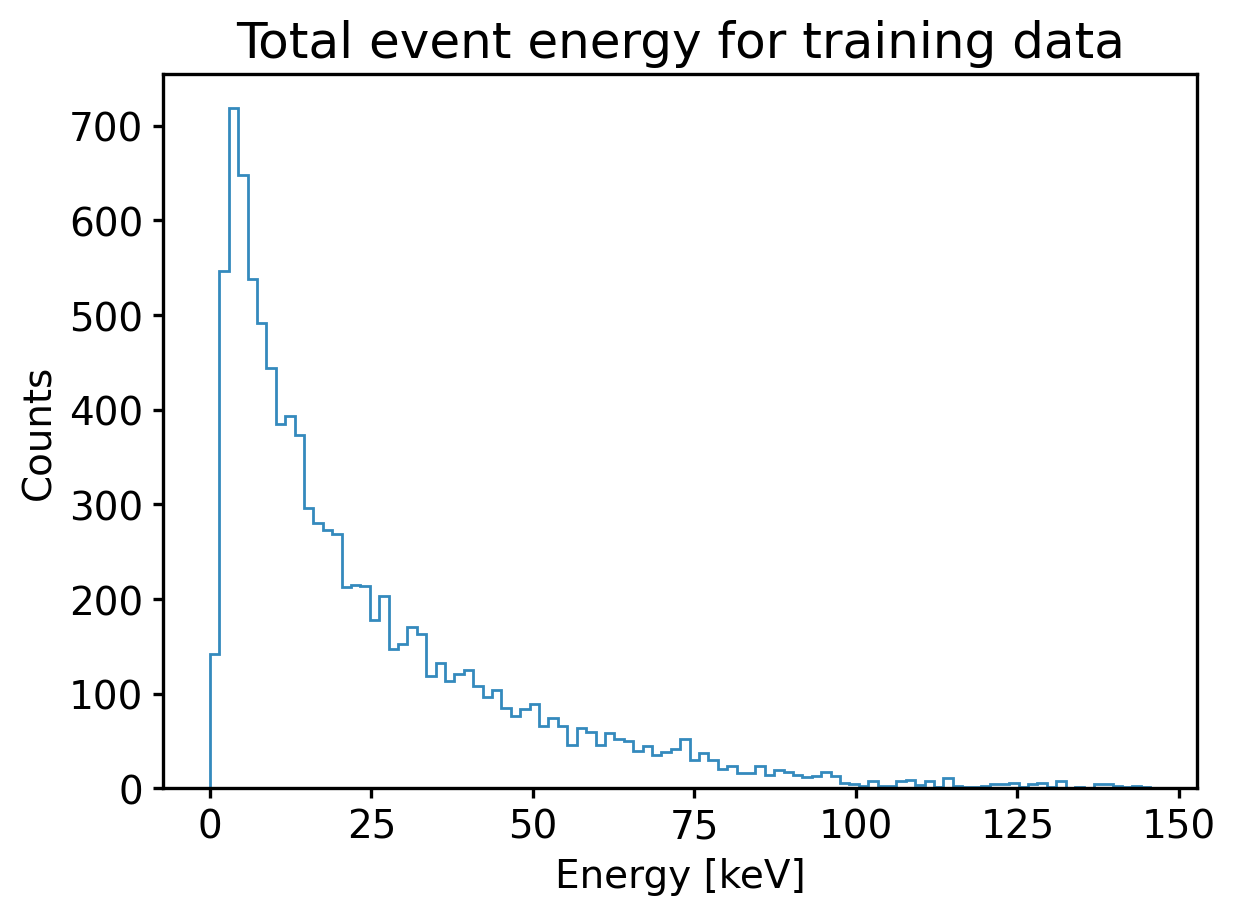

In [108]:
fig, ax = plt.subplots()
ax.hist(sim_data[:,1] + sim_data[:,5],histtype='step', bins=100)
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')
ax.set_title('Total event energy for training data')
# ax.set_xlim([0, 20])
# ax.set_ylim([0, 20])
fig.savefig('/home/clarke/figures/sim_data_spec.png')